In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, precision_recall_curve, average_precision_score, auc, RocCurveDisplay
import shap
from sklearn.dummy import DummyClassifier

c:\Users\ankit\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
amino_acids = "ACDEFGHIKLMNPQRSTVWY-"

def extract_features(sequence):
    sequence = sequence.upper()
    seq_len = len(sequence)
    counts = {aa: sequence.count(aa)/seq_len for aa in amino_acids}
    return counts

In [3]:
train_df = pd.read_csv(r"D:\Thesis EGFR Round 3\Dataset\Clustering\70\data\changed_train_seqs_new.csv")
val_df = pd.read_csv(r"D:\Thesis EGFR Round 3\Dataset\Clustering\70\data\changed_val_seqs_validation.csv")

In [ ]:
train_cdr1 = pd.DataFrame.from_records([extract_features(cdr) for cdr in train_df['CDR1 aligned']])
train_cdr2 = pd.DataFrame.from_records([extract_features(cdr) for cdr in train_df['CDR2 aligned']])
train_cdr3 = pd.DataFrame.from_records([extract_features(cdr) for cdr in train_df['CDR3 aligned']])

In [5]:
train_cdr1.columns = [f"CDR1_{aa}" for aa in train_cdr1.columns]
train_cdr2.columns = [f"CDR2_{aa}" for aa in train_cdr2.columns]
train_cdr3.columns = [f"CDR3_{aa}" for aa in train_cdr3.columns]

In [6]:
val_cdr1 = pd.DataFrame.from_records([extract_features(cdr) for cdr in val_df['CDR1 aligned']])
val_cdr2 = pd.DataFrame.from_records([extract_features(cdr) for cdr in val_df['CDR2 aligned']])
val_cdr3 = pd.DataFrame.from_records([extract_features(cdr) for cdr in val_df['CDR3 aligned']])

In [7]:
val_cdr1.columns = [f"CDR1_{aa}" for aa in val_cdr1.columns]
val_cdr2.columns = [f"CDR2_{aa}" for aa in val_cdr2.columns]
val_cdr3.columns = [f"CDR3_{aa}" for aa in val_cdr3.columns]

In [8]:
x_train = pd.concat([train_cdr1, train_cdr2, train_cdr3], axis=1)
y_train = train_df['Label'].values
x_val = pd.concat([val_cdr1, val_cdr2, val_cdr3], axis=1)
y_val = val_df['Label'].values

In [ ]:

clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12, 
    min_samples_leaf=3, 
    min_samples_split=10,
    n_jobs=-1, 
    max_features="sqrt", 
    class_weight="balanced", 
    random_state=42 
    )
clf.fit(x_train, y_train)
print("Number of features:", clf.n_features_in_)

Number of features: 63


In [10]:
x_val = x_val[x_train.columns]

In [11]:
y_pred = clf.predict(x_val)
y_scores = clf.predict_proba(x_val)[:, 1]
print("Accuracy:", accuracy_score(y_val, y_pred))
print("Precision:", precision_score(y_val, y_pred))
print("Recall:", recall_score(y_val, y_pred))
print("F1 Score:", f1_score(y_val, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_pred))
print("\nClassification Report:\n", classification_report(y_val, y_pred))
print("\nROC AUC Score:", roc_auc_score(y_val, clf.predict_proba(x_val)[:, 1]))

Accuracy: 0.5838235294117647
Precision: 0.5373015873015873
Recall: 0.5522022838499184
F1 Score: 0.5446500402252614

Confusion Matrix:
 [[911 583]
 [549 677]]

Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.61      0.62      1494
           1       0.54      0.55      0.54      1226

    accuracy                           0.58      2720
   macro avg       0.58      0.58      0.58      2720
weighted avg       0.58      0.58      0.58      2720


ROC AUC Score: 0.6180202047996226


In [ ]:
y_train_pred = clf.predict(x_train)

print("Training Accuracy:", accuracy_score(y_train, y_train_pred))
print("Validation Accuracy:", accuracy_score(y_val, y_pred))

Training Accuracy: 0.7210071678000367
Validation Accuracy: 0.5838235294117647


In [ ]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(x_train, y_train)
print("Baseline accuracy:", dummy.score(x_val, y_val))


Baseline accuracy: 0.549264705882353


In [14]:
precision, recall, thresholds = precision_recall_curve(y_val, y_scores)
ap = average_precision_score(y_val, y_scores)
print("Average precision:", ap)
pr_auc = auc(recall, precision)
print("PR AUC (AUC over PR curve):", pr_auc)

Average precision: 0.559055658769096
PR AUC (AUC over PR curve): 0.5582899473277535


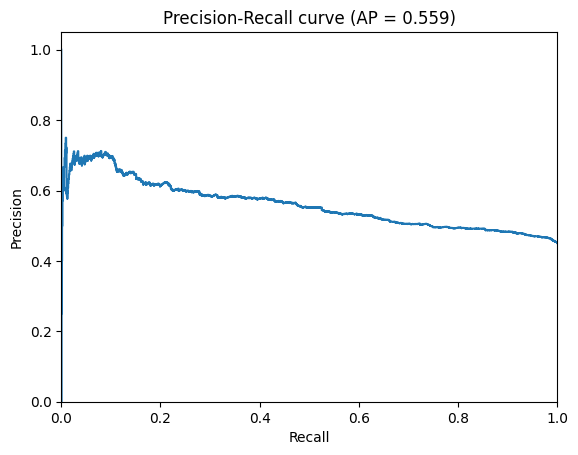

In [15]:
plt.figure()
plt.step(recall, precision, where="post")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall curve (AP = {ap:.3f})")
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.show()

C:\Users\ankit\AppData\Local\Temp\ipykernel_11224\982723069.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df.head(20), x='Importance', y='Feature', palette='viridis')


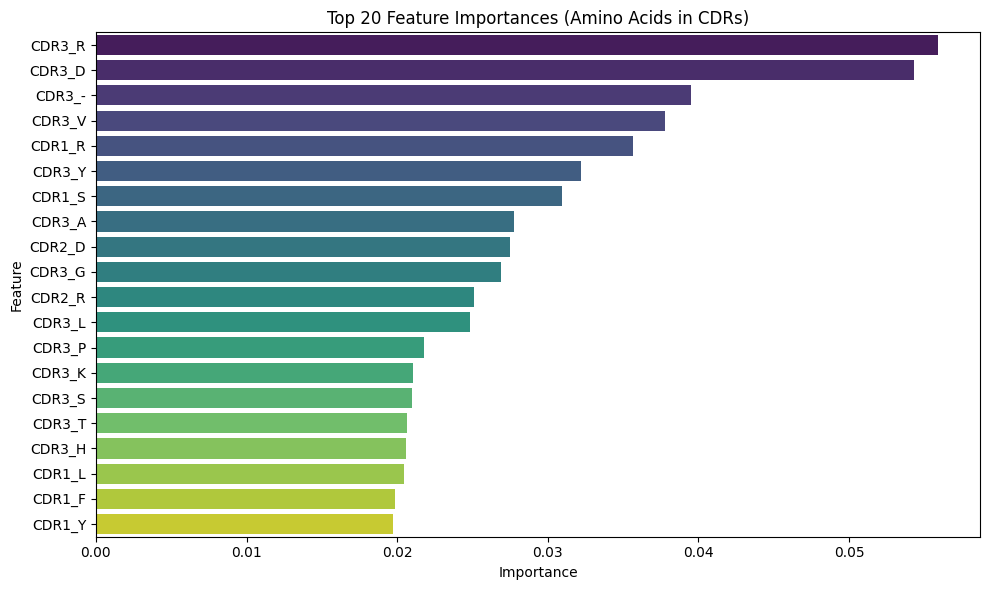

In [ ]:
feat_df = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': clf.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_df.head(20), x='Importance', y='Feature', palette='viridis')
plt.title('Top 20 Feature Importances (Amino Acids in CDRs)')
plt.tight_layout()
plt.show()

C:\Users\ankit\AppData\Local\Temp\ipykernel_11224\3959690622.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=group_importance, x='Importance', y='Group', palette='Set2')


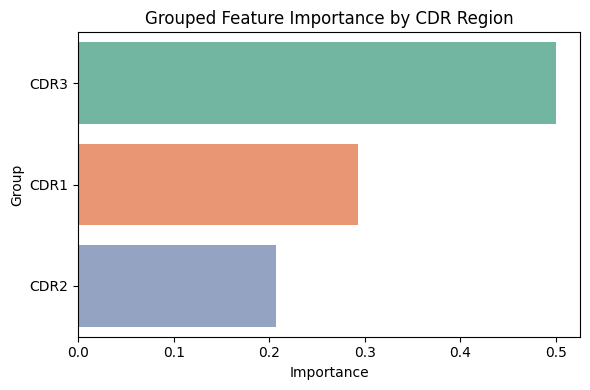

In [ ]:
feat_df['Group'] = feat_df['Feature'].astype(str).str.extract(r'^(CDR\d+)_')
group_importance = feat_df.groupby('Group')['Importance'].sum().reset_index().sort_values(by='Importance', ascending=False)

plt.figure(figsize=(6, 4))
sns.barplot(data=group_importance, x='Importance', y='Group', palette='Set2')
plt.title('Grouped Feature Importance by CDR Region')
plt.tight_layout()
plt.show()


C:\Users\ankit\AppData\Local\Temp\ipykernel_11224\2369169635.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=aa_importance, x='Importance', y='AA', palette='coolwarm')


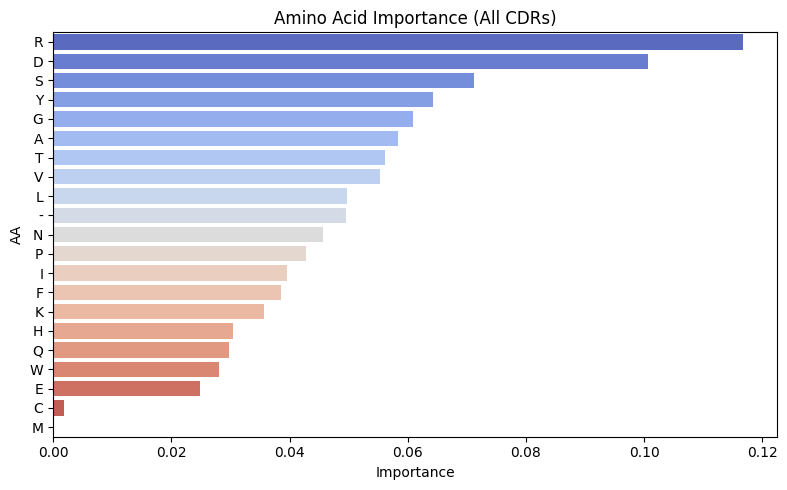

In [ ]:
feat_df['AA'] = feat_df['Feature'].str.extract(r'_([A-Z\-])$') 
aa_importance = feat_df.groupby('AA')['Importance'].sum().reset_index().sort_values(by='Importance', ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(data=aa_importance, x='Importance', y='AA', palette='coolwarm')
plt.title('Amino Acid Importance (All CDRs)')
plt.tight_layout()
plt.show()

Test set evaluation

In [19]:
test_df = pd.read_csv(r"D:\Thesis EGFR Round 3\Dataset\Clustering\70\data\changed_test_seqs_new.csv")
test_cdr1 = pd.DataFrame.from_records([extract_features(cdr) for cdr in test_df['CDR1 aligned']])
test_cdr2 = pd.DataFrame.from_records([extract_features(cdr) for cdr in test_df['CDR2 aligned']])
test_cdr3 = pd.DataFrame.from_records([extract_features(cdr) for cdr in test_df['CDR3 aligned']])

In [20]:
test_cdr1.columns = [f"CDR1_{aa}" for aa in test_cdr1.columns]
test_cdr2.columns = [f"CDR2_{aa}" for aa in test_cdr2.columns]
test_cdr3.columns = [f"CDR3_{aa}" for aa in test_cdr3.columns]


In [21]:
x_test = pd.concat([test_cdr1, test_cdr2, test_cdr3], axis=1)
y_test = test_df['Label'].values
clusters_test = test_df["Cluster_number"].values

In [22]:
x_test = x_test[x_train.columns]

In [23]:
val_test_df = pd.read_csv(r"D:\Thesis EGFR Round 3\Dataset\Clustering\70\data\changed_val_seqs_test.csv")
val_test_cdr1 = pd.DataFrame.from_records([extract_features(cdr) for cdr in val_test_df['CDR1 aligned']])
val_test_cdr2 = pd.DataFrame.from_records([extract_features(cdr) for cdr in val_test_df['CDR2 aligned']])
val_test_cdr3 = pd.DataFrame.from_records([extract_features(cdr) for cdr in val_test_df['CDR3 aligned']])
val_test_cdr1.columns = [f"CDR1_{aa}" for aa in val_test_cdr1.columns]
val_test_cdr2.columns = [f"CDR2_{aa}" for aa in val_test_cdr2.columns]
val_test_cdr3.columns = [f"CDR3_{aa}" for aa in val_test_cdr3.columns]
x_test_val = pd.concat([val_test_cdr1, val_test_cdr2, val_test_cdr3], axis=1)
y_test_val = val_test_df['Label'].values
clusters_test_val = val_test_df["Cluster_number"].values

In [24]:
def evaluate_split(clf, x, y, split_name="Test"):
    y_scores = clf.predict_proba(x)[:, 1]
    y_pred = (y_scores >= 0.5).astype(int)

    acc = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred, zero_division=0)
    rec = recall_score(y, y_pred, zero_division=0)
    f1 = f1_score(y, y_pred, zero_division=0)
    cm = confusion_matrix(y, y_pred)

    roc_auc = roc_auc_score(y, y_scores)
    p, r, _ = precision_recall_curve(y, y_scores)
    pr_auc = auc(r, p)

    print(f"\n================ FULL {split_name.upper()} SET ================\n")
    print(f"Accuracy:  {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall:    {rec:.3f}")
    print(f"F1:        {f1:.3f}")
    print("\nConfusion matrix:")
    print(cm)
    print(f"\nROC-AUC:   {roc_auc:.3f}")
    print(f"PR-AUC:    {pr_auc:.3f}")

    return {
        "y_scores": y_scores,
        "y_pred": y_pred,
        "acc": acc,
        "prec": prec,
        "rec": rec,
        "f1": f1,
        "cm": cm,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc
    }


In [ ]:
def evaluate_at_k(y_true, y_scores, clusters, k=100, split_name="Test"):
    y_true = np.asarray(y_true)
    y_scores = np.asarray(y_scores)
    clusters = np.asarray(clusters)

    assert len(y_true) == len(y_scores), "y_true and y_scores must have same length"
    assert len(y_true) == len(clusters), "y_true and clusters must have same length"

    k = min(k, len(y_true))
    top_idx = np.argsort(y_scores)[::-1][:k]
    y_topk = y_true[top_idx]

    # precision@k
    precision_k = y_topk.sum() / k
    total_positives = y_true.sum()

    # precision@1000
    k_1000 = min(1000, len(y_true))
    top_idx_1000 = np.argsort(y_scores)[::-1][:k_1000]
    precision_1000 = y_true[top_idx_1000].sum() / k_1000

    # ef@k
    positive_rate = total_positives / len(y_true)
    ef_k = (precision_k / positive_rate) if positive_rate > 0 else np.nan

    # diversity@k
    diversity_k = len(np.unique(clusters[top_idx]))

    # normalized diversity@k
    total_unique_clusters = len(np.unique(clusters))
    normalized_diversity_k = (
        diversity_k / total_unique_clusters if total_unique_clusters > 0 else np.nan
    )
    
    print(f"\n================ {split_name.upper()} @ {k} ================\n")

    print(f"Precision@{k}:            {precision_k:.3f}")
    print(f"Precision@1000:           {precision_1000:.3f}")
    print(f"EF@{k}:                   {ef_k:.3f}" if not np.isnan(ef_k) else f"EF@{k}:NaN")

    print(f"Diversity@{k}:            {diversity_k}")
    print(f"Normalized Diversity@{k}: {normalized_diversity_k:.3f}" 
      if not np.isnan(normalized_diversity_k) 
      else f"Normalized Diversity@{k}: NaN")

    return {
        "top_idx": top_idx,
        f"precision@{k}": precision_k,
        f"precision@1000": precision_1000,
        f"ef@{k}": ef_k,
        f"diversity@{k}": diversity_k,
        f"normalized_diversity@{k}": normalized_diversity_k
    }


In [26]:
test_results = evaluate_split(clf, x_test, y_test, split_name="Test")
test_at_100 = evaluate_at_k(y_test, test_results["y_scores"], clusters_test, k=100, split_name="Test")

val_test_results = evaluate_split(clf, x_test_val, y_test_val, split_name="Validation")
val_test_at_100 = evaluate_at_k(y_test_val, val_test_results["y_scores"], clusters_test_val, k=100, split_name="Validation")


================ FULL TEST SET ================

Accuracy:  0.586
Precision: 0.574
Recall:    0.574
F1:        0.574

Confusion matrix:
[[11263  7568]
 [ 7570 10188]]

ROC-AUC:   0.620
PR-AUC:    0.603

================ TEST @ 100 ================

Precision@100:            0.850
Precision@1000:           0.774
EF@100:                   1.751
Diversity@100:            92
Normalized Diversity@100: 0.005

================ FULL VALIDATION SET ================

Accuracy:  0.580
Precision: 0.534
Recall:    0.531
F1:        0.533

Confusion matrix:
[[926 569]
 [574 651]]

ROC-AUC:   0.613
PR-AUC:    0.554

================ VALIDATION @ 100 ================

Precision@100:            0.630
Precision@1000:           0.552
EF@100:                   1.399
Diversity@100:            91
Normalized Diversity@100: 0.040


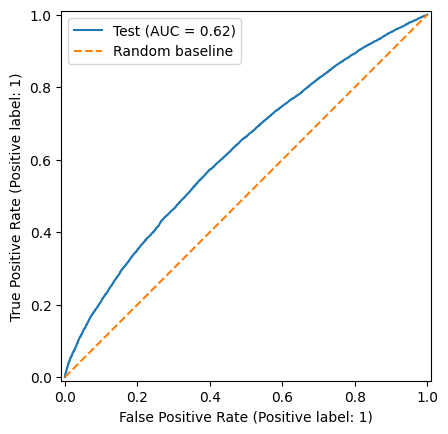

In [27]:
RocCurveDisplay.from_predictions(y_test, test_results["y_scores"], name="Test")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random baseline")
plt.legend()
plt.show()


In [ ]:

model_name = "RF_CDRs"
seq_sim = 70

metrics_row = pd.DataFrame({
    "Model": [model_name],
    "Sequence_Similarity": [seq_sim],
    "Accuracy_test": [test_results["acc"]],
    "Precision_test": [test_results["prec"]],
    "Recall_test": [test_results["rec"]],
    "F1_test": [test_results["f1"]],
    "ROC_AUC_test": [test_results["roc_auc"]],
    "PR_AUC_test": [test_results["pr_auc"]],

    "Precision@100_test": [test_at_100["precision@100"]],
    "Precision@1000_test": [test_at_100["precision@1000"]],
    "EF@100_test": [test_at_100["ef@100"]],
    "Diversity@100_test": [test_at_100["diversity@100"]],
    "Normalized_Diversity@100_test": [test_at_100["normalized_diversity@100"]],

    "Precision@100_val": [val_test_at_100["precision@100"]],
    "Precision@1000_val": [val_test_at_100["precision@1000"]],
    "EF@100_val": [val_test_at_100["ef@100"]],
    "Diversity@100_val": [val_test_at_100["diversity@100"]],
    "Normalized_Diversity@100_val": [val_test_at_100["normalized_diversity@100"]],

    "N_test": [len(y_test)],
    "N_val": [len(y_test_val)]
})

metrics_file = r"D:\Thesis EGFR Round 3\Baseline Models\Results\metrics_all_models_70.csv"

metrics_row.to_csv(
    metrics_file,
    mode='a',
    header=not os.path.exists(metrics_file),
    index=False
)

print("Metrics saved.")


Metrics saved.


In [29]:
def get_topk_df(df, y_true, y_scores, y_pred, top_idx):
    topk_df = df.iloc[top_idx].copy().assign(
        y_true=y_true[top_idx],
        pred_score=y_scores[top_idx],
        pred_label=y_pred[top_idx]
    )
    tp_topk_df = topk_df[
        (topk_df["y_true"] == 1) & (topk_df["pred_label"] == 1)
    ].copy()
    return tp_topk_df


In [30]:
tp_top100_df = get_topk_df(test_df, y_test, test_results["y_scores"], test_results["y_pred"], test_at_100["top_idx"])

In [31]:
export_df = tp_top100_df[[
    "Cluster_number",
    "Nanobody_id",
    "Label",
    "pred_label",
    "pred_score",
    "Sequence",
    "CDR1",
    "CDR2",
    "CDR3",
    "CDR1 aligned",
    "CDR2 aligned",
    "CDR3 aligned",
    "Aligned Sequence",
    "CDR_sequence"
]]



In [32]:
export_df.to_csv(r"D:\Thesis EGFR Round 3\Dataset\Clustering\70\Predictions\regularized_count_cdrs.csv", index=False)
print("Saved only confident predictions to confident_predictions.csv")
print("Number of confident predictions:", len(export_df))


Saved only confident predictions to confident_predictions.csv
Number of confident predictions: 85


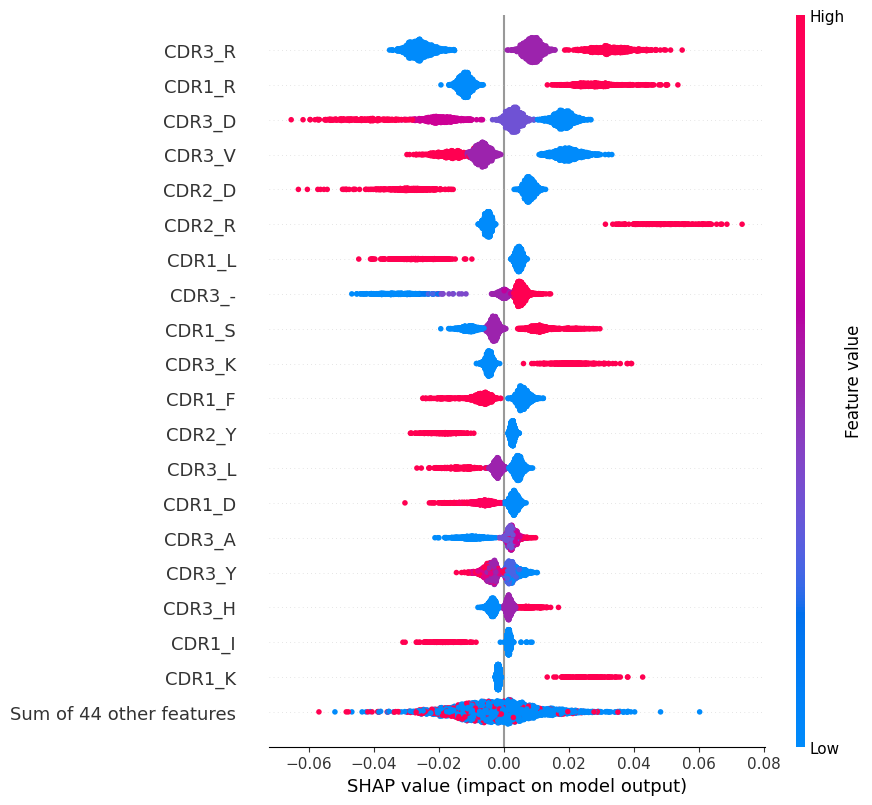

In [ ]:
subset = x_test.sample(2000, random_state=42)

explainer = shap.TreeExplainer(clf)
sv = explainer(subset)          
if sv.values.ndim == 3:
    class_idx = 1
    sv = shap.Explanation(
        values=sv.values[:, :, class_idx],
        base_values=sv.base_values[:, class_idx],
        data=sv.data,
        feature_names=sv.feature_names
    )

shap.plots.beeswarm(sv, max_display=20)


Number of label 1 sequences in top-100: 85


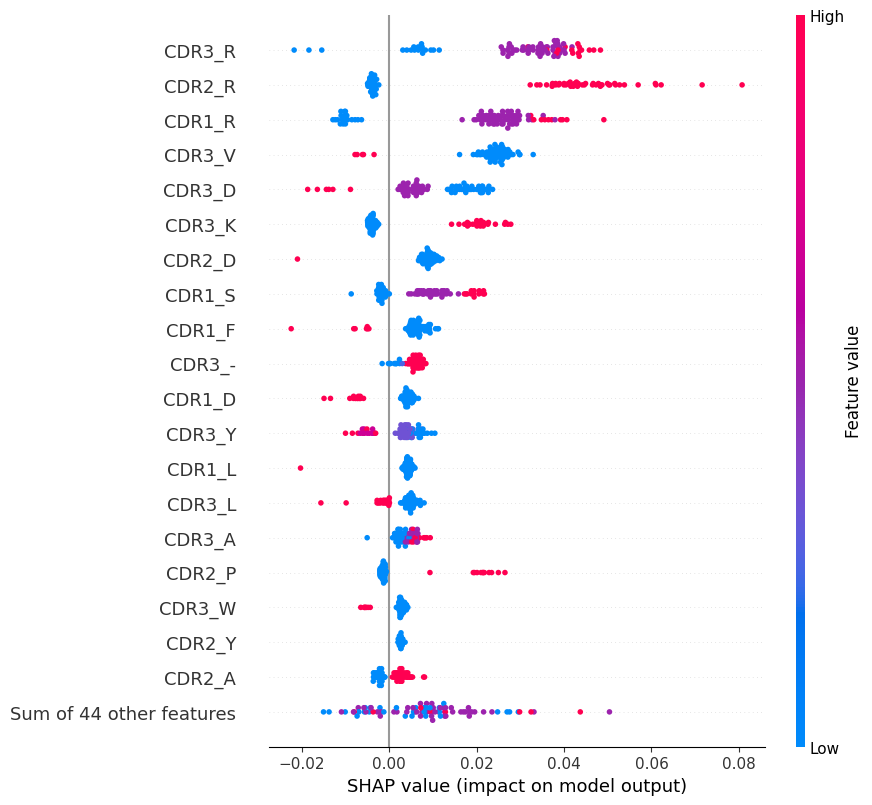

In [ ]:
k =100
top_idx_shap = np.argsort(-test_results["y_scores"])[:k]
top100_label1_idx = top_idx_shap[y_test[top_idx_shap] == 1]
print("Number of label 1 sequences in top-100:", len(top100_label1_idx))
subset_top100_pos = x_test.iloc[top100_label1_idx]
explainer_100 = shap.TreeExplainer(clf)
sv_100 = explainer_100(subset_top100_pos)

if sv_100.values.ndim == 3:
    class_idx = 1
    sv_100 = shap.Explanation(
        values=sv_100.values[:, :, class_idx],
        base_values=sv_100.base_values[:, class_idx],
        data=sv_100.data,
        feature_names=sv_100.feature_names
    )

shap.plots.beeswarm(sv_100, max_display=20)